<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/CNN_Computer_Vision/03_DCL_Treinamento_de_Anotacoes_Frames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objetivo desta etapa:
- Treinar a arquitetura ResNet-50 para reconhecer pontos anatômicos (cascos/articulações) nos frames selecionados. O resultado esperado é uma rede capaz de automatizar a anotação dos frames restantes do vídeo. Analisar a aplicação de hiperparâmetros diferentes, análise de métricas e diversidade de banco de dados.
- Treinamentos serão feitos com dados locais, para uma melhor performance e maior velocidade, em seguida copiados no Drive.
- Criação de gráfico Loss para verificar a performance de treino.
- Análise, métricas de treino e validação, estarão no arquivo PerformanceIndicators.md do repositório: https://github.com/vitoriaferreirap/DeepLearning/blob/main/PerformanceIndicators.md


In [ ]:
!unzip -q /content/EstimativaPose-Cavalos-2026-03-06.zip -d /content/EstimativaPose_LOCAL

In [ ]:
# traz para os arquivos para pasta principal
!mv /content/EstimativaPose_LOCAL/EstimativaPose-Cavalos-2026-03-06/* /content/EstimativaPose_LOCAL/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# O ponto (.) indica "copie o conteúdo para aqui, na raiz atual"
!cp -r /content/drive/MyDrive/deeplabcut/EstimativaPose_BACKUP/. /content/EstimativaPose_BACKUP

Exibindo diagnóstico: /content/EstimativaPose_BACKUP/labeled-videos/plot-poses/8/plot-likelihood.png


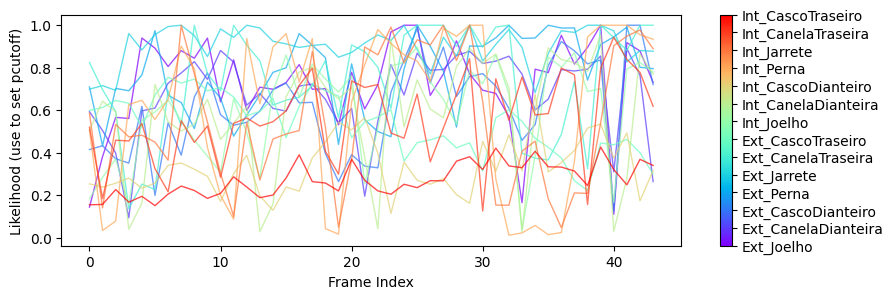

In [ ]:
import os
from IPython.display import Image, display

# Busca automática e exibição direta
encontrado = False
for root, dirs, files in os.walk(f"/content/EstimativaPose_BACKUP"):
    for file in files:
        if "likelihood" in file.lower() and file.endswith(".png"):
            caminho = os.path.join(root, file)
            print(f"Exibindo diagnóstico: {caminho}")
            display(Image(filename=caminho))
            encontrado = True
            break # Mostra apenas o primeiro para não encher a tela
    if encontrado: break

if not encontrado:
    print("Gráfico não encontrado. Rode: deeplabcut.plot_trajectories(path_config_file, videofile_path, destfolder=destfolder)")

In [ ]:
!pip install --pre deeplabcut

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━

In [ ]:
import deeplabcut

Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


## Create a training dataset:


In [ ]:
path_config_local = 'EstimativaPose_LOCAL/config.yaml'

deeplabcut.create_training_dataset(
    path_config_local,
    net_type="resnet_50",
    num_shuffles=1,
    engine=deeplabcut.Engine.PYTORCH,
    augmenter_type='imgaug'
)

[(0.95,
  1,
  (array([ 55, 181,  92, 207, 188,  45, 111, 239,  15,  22, 267, 194,  12,
           81,  63, 191, 225, 171, 201, 136, 154, 236, 101, 279, 106, 110,
          218, 227, 126, 284, 213,   8,   5, 200,  90, 280,  97, 103,   7,
           64,  73, 159, 179, 205, 241, 124, 158, 208,  74, 270,  59, 278,
          271, 222,  76, 150, 252,  20,  46, 257, 214, 167, 223, 168,  27,
          135, 245,  37, 210, 153, 161, 116, 250, 190, 215, 224, 134, 277,
           89,  44, 228, 199, 166, 268,  54, 129,  18, 156, 235, 233, 234,
           71, 246, 230, 272, 274, 145,  33,  83, 118,  60, 146, 266,  21,
           29, 137,  16,  56,  75, 184, 139, 152, 220, 109, 122,   4,  96,
          157,  61, 108,  67,  52, 229,  66,  26, 144, 187, 216, 265,  40,
          175,  13, 107, 262,   3, 160, 125,  24,  30,  77, 264, 176,  19,
          238, 217, 254,  80,  51,   2, 221, 104, 189,  86,  10, 182,  58,
           41,  14, 155,  50, 198, 219, 123,  62, 260, 212, 130, 206, 173,
           4

In [ ]:
project_folder_local = "EstimativaPose_BACKUP"

videofile_path = [
  f"/content/{project_folder_local}/videos/1.mp4",
  f"/content/{project_folder_local}/videos/2.mp4",
  f"/content/{project_folder_local}/videos/3.mp4",
  f"/content/{project_folder_local}/videos/4.mp4",
  f"/content/{project_folder_local}/videos/5.mp4",
  f"/content/{project_folder_local}/videos/6.mp4",
  f"/content/{project_folder_local}/videos/7.mp4",
  f"/content/{project_folder_local}/videos/8.mp4",
  f"/content/{project_folder_local}/videos/9.mp4",
  f"/content/{project_folder_local}/videos/10.mp4"
]

# Onde os vídeos analisados serão salvos temporariamente
destfolder = f"/content/{project_folder_local}/labeled-videos"

# O arquivo de configuração que o DeepLabCut vai ler para o treino
path_config_file = f"/content/{project_folder_local}/config.yaml"

print(f"Caminho do Config Local: {path_config_file}")
print(f"Primeiro vídeo local: {videofile_path[0]}")

Caminho do Config Local: /content/EstimativaPose_BACKUP/config.yaml
Primeiro vídeo local: /content/EstimativaPose_BACKUP/videos/1.mp4


## Treinamento

In [ ]:
deeplabcut.train_network(
    path_config_file,
    shuffle=1,
    trainingsetindex=0,
    device="cuda:0",
    max_snapshots_to_keep=5,
    displayiters=100,
    save_epochs=100,
    epochs=700,
    saveiters=500
)

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: /content/EstimativaPose_LOCAL
  pose_config_path: /content/EstimativaPose_LOCAL/dlc-models-pytorch/iteration-0/EstimativaPoseMar6-trainset95shuffle1/train/pytorch_config.yaml
  bodyparts: ['Ext_Joelho', 'Ext_CanelaDianteira', 'Ext_CascoDianteiro', 'Ext_Perna', 'Ext_Jarrete', 'Ext_CanelaTraseira', 'Ext_CascoTraseiro', 'Int_Joelho', 'Int_CanelaDianteira', 'Int_CascoDianteiro', 'Int_Perna', 'Int_Jarrete', 'Int_

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[timm/resnet50_gn.a1h_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
Data Transforms:
  Training:   Compose([
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (0.5, 1.25), 'y': (0.5, 1.25)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  PadIfNeeded(always_apply=True, p=1.0, min_height=448, min_width=448, pad_height_divisor=None, pad_width_divisor=None, position=PositionType.CENTER, border_mode=0, value=None, mask_value=None),
  KeypointAwareCrop(always_apply=True, p=1.0, width=448, height=448, max_shift=0.1, crop_sampling='hybrid'),
  MotionBlur(always_apply=False, p=0.5, blur_limit=(3, 7), allow_shifted=True),
  GaussNoise(always_apply=False, p=0.5, var_limit=(0, 162.5625), per_channel=True, mean=0),
  Nor

## Análise


In [ ]:
deeplabcut.evaluate_network(path_config_file, plotting=True)

Evaluation scorer: DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700


100%|██████████| 15/15 [00:05<00:00,  2.73it/s]


Evaluation results file: DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700-results.csv
Evaluation results for DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700-results.csv (pcutoff: 0.5):
train rmse            24.92
train rmse_pcutoff     6.36
train mAP             83.91
train mAR             87.81
test rmse             27.75
test rmse_pcutoff      8.43
test mAP              86.08
test mAR              88.00
Name: (0.95, 1, 700, -1, 0.5), dtype: float64


## Gráfico de Confiança (Likelihood)

## Cria gráfico Loss


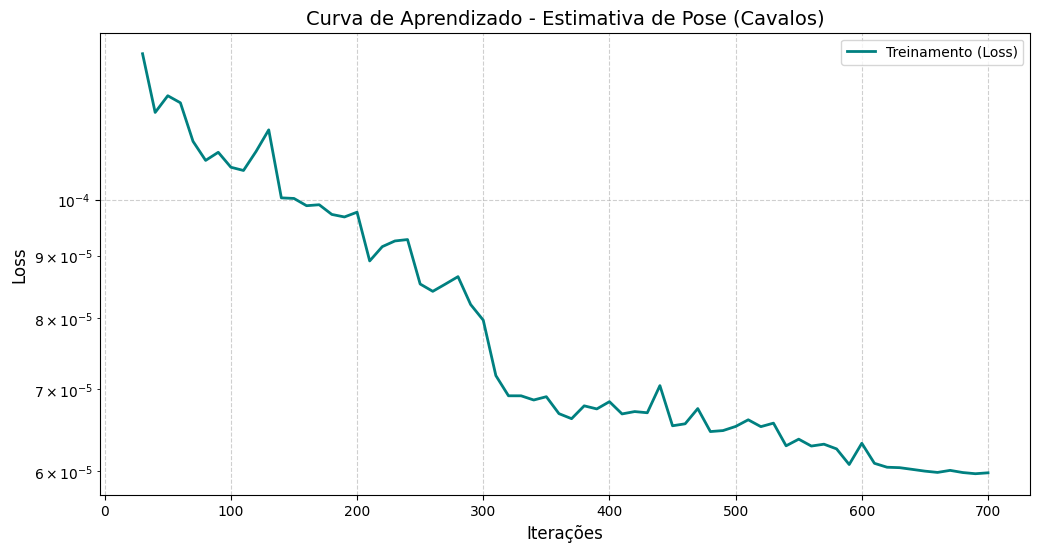

Gráfico gerado! Total de pontos processados: 68


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = "/content/EstimativaPose_LOCAL/dlc-models-pytorch/iteration-0/EstimativaPoseMar6-trainset95shuffle1/train/learning_stats.csv"

if os.path.exists(csv_path):
    # Lendo o CSV e garantindo que os dados sejam numéricos
    try:
        data = pd.read_csv(csv_path, header=None)

        # O DLC salva 3 colunas: Iteração, Loss, LR
        # Vamos converter para numérico, transformando erros em 'NaN' e depois removendo-os
        data[0] = pd.to_numeric(data[0], errors='coerce')
        data[1] = pd.to_numeric(data[1], errors='coerce')
        data = data.dropna()

        plt.figure(figsize=(12, 6))
        plt.plot(data[0], data[1], color='teal', linewidth=2, label='Treinamento (Loss)')

        plt.title('Curva de Aprendizado - Estimativa de Pose (Cavalos)', fontsize=14)
        plt.xlabel('Iterações', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)

        # Escala logarítmica é melhor para ver o Loss chegando perto de zero
        plt.yscale('log')
        plt.legend()

        plt.show()
        print(f"Gráfico gerado! Total de pontos processados: {len(data)}")

    except Exception as e:
        print(f"Erro ao processar os dados: {e}")
else:
    print("Arquivo learning_stats.csv não encontrado no caminho.")

## Análise vídeos:
Esta função analisa o novo vídeo. O usuário pode escolher o melhor modelo a partir dos resultados da avaliação e especificar o índice correto do snapshot para a variável ` snapshotindex` no arquivo `config.yaml` . Caso contrário, por padrão, o snapshot mais recente é usado para analisar o vídeo.

Os resultados são armazenados em um arquivo hd5 no mesmo diretório onde o vídeo está localizado.

In [ ]:
deeplabcut.analyze_videos(
    path_config_file,
    videofile_path,
    videotype='.mp4',
    destfolder=destfolder,
)

Creating the output folder /content/EstimativaPose_LOCAL/labeled-videos
Analyzing videos with /content/EstimativaPose_LOCAL/dlc-models-pytorch/iteration-0/EstimativaPoseMar6-trainset95shuffle1/train/snapshot-best-700.pt
Using scorer: DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700
Starting to analyze /content/EstimativaPose_LOCAL/videos/1.mp4
Video metadata: 
  Overall # of frames:    78
  Duration of video [s]:  5.20
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


100%|██████████| 78/78 [00:22<00:00,  3.46it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/1DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700.h5 and /content/EstimativaPose_LOCAL/labeled-videos/1DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700_full.pickle
Starting to analyze /content/EstimativaPose_LOCAL/videos/2.mp4
Video metadata: 
  Overall # of frames:    46
  Duration of video [s]:  3.07
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


100%|██████████| 46/46 [00:12<00:00,  3.56it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/2DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700.h5 and /content/EstimativaPose_LOCAL/labeled-videos/2DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700_full.pickle
Starting to analyze /content/EstimativaPose_LOCAL/videos/3.mp4
Video metadata: 
  Overall # of frames:    54
  Duration of video [s]:  3.60
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


...

100%|██████████| 69/69 [00:22<00:00,  3.13it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/9DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700.h5 and /content/EstimativaPose_LOCAL/labeled-videos/9DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700_full.pickle
Starting to analyze /content/EstimativaPose_LOCAL/videos/10.mp4
Video metadata: 
  Overall # of frames:    128
  Duration of video [s]:  8.53
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


100%|██████████| 128/128 [00:41<00:00,  3.06it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/10DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700.h5 and /content/EstimativaPose_LOCAL/labeled-videos/10DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-700'

## Trace as trajetórias dos vídeos analisados:
Esta função traça as trajetórias de todas as partes do corpo ao longo de todo o vídeo. Cada parte do corpo é identificada por uma cor única.

In [ ]:
deeplabcut.plot_trajectories(
    path_config_file,
    videofile_path,
    videotype='.mp4',
    destfolder=destfolder,
)

Loading  /content/EstimativaPose_LOCAL/videos/1.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/2.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/3.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/4.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/5.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/6.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/7.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/8.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/9.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/10.mp4 and data.
Plots created! Please check the directory "plot-poses" within the video directory


## Criar vídeo com legendas:
Esta função serve para fins de visualização e pode ser usada para criar um vídeo em formato .mp4 com rótulos previstos pela rede. Este vídeo é salvo no mesmo diretório onde o vídeo original está localizado.

In [ ]:
deeplabcut.create_labeled_video(
    path_config_file,
    videofile_path,
    videotype='.mp4',
    destfolder=destfolder,
)

Starting to process video: /content/EstimativaPose_LOCAL/videos/3.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/1.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/2.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/4.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/5.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/6.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/7.mp4



Loading /content/EstimativaPose_LOCAL/videos/3.mp4 and data.
Loading /content/EstimativaPose_LOCAL/videos/1.mp4 and data.

Loading /content/EstimativaPose_LOCAL/videos/2.mp4 and data.

Loading /content/EstimativaPose_LOCAL/videos/7.mp4 and data.Loading /content/EstimativaPose_LOCAL/videos/6.mp4 and data.
Loading /content/EstimativaPose_LOCAL/videos/5.mp4 and data.


Loading /content/EstimativaPose_LOCAL/videos/4.mp4 and data.Starting to process video: /content/EstimativaPose_LOCAL/videos/8.mp4

Loading /cont

  0%|          | 0/49 [00:00<?, ?it/s]


Generating frames and creating video.Generating frames and creating video.

  0%|          | 0/56 [00:00<?, ?it/s]

Duration of video [s]: 2.93, recorded with 15.0 fps!





...

Duration of video [s]: 8.53, recorded with 15.0 fps!
Duration of video [s]: 4.6, recorded with 15.0 fps!Overall # of frames: 128 with cropped frame dimensions: 2208 1242

Overall # of frames: 69 with cropped frame dimensions: 2208 1242Generating frames and creating video.



  0%|          | 0/128 [00:00<?, ?it/s]

Generating frames and creating video.


100%|██████████| 128/128 [00:03<00:00, 33.39it/s]


[True, True, True, True, True, True, True, True, True, True]